<a href="https://colab.research.google.com/github/tonygthomas/XAI_NIDS/blob/main/FinalCapstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap

from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.neighbors import NearestCentroid
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')
%matplotlib inline

In [ ]:
train = pd.read_csv("Dataset/Train.txt")

columns = ['duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent','hot',
'num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root','num_file_creations',
'num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count','srv_count','serror_rate',
'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count',
'dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate',
'dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate','dst_host_rerror_rate',
'dst_host_srv_rerror_rate','attack','level']

train.columns = columns
train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,level
0,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.0,0.0,0.0,0.0,0.08,0.15,0.00,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.0,0.00,normal,15
1,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.0,1.0,0.0,0.0,0.05,0.07,0.00,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.0,0.00,neptune,19
2,0,tcp,http,SF,232,8153,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,5,5,0.2,0.2,0.0,0.0,1.00,0.00,0.00,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.0,0.01,normal,21
3,0,tcp,http,SF,199,420,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,30,32,0.0,0.0,0.0,0.0,1.00,0.00,0.09,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,normal,21
4,0,tcp,private,REJ,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,121,19,0.0,0.0,1.0,1.0,0.16,0.06,0.00,255,19,0.07,0.07,0.00,0.00,0.00,0.00,1.0,1.00,neptune,21


In [ ]:
attack_map = {
    'normal': 0,
    # DoS
    'back': 1, 'land': 1, 'pod': 1, 'neptune': 1, 'smurf': 1, 'teardrop': 1,
    'apache2': 1, 'udpstorm': 1, 'processtable': 1, 'worm': 1, 'mailbomb': 1,
    # Probe
    'satan': 2, 'ipsweep': 2, 'nmap': 2, 'portsweep': 2, 'mscan': 2, 'saint': 2,
    # R2L
    'guess_passwd': 3, 'ftp_write': 3, 'imap': 3, 'phf': 3, 'multihop': 3,
    'warezmaster': 3, 'warezclient': 3, 'spy': 3, 'xlock': 3, 'xsnoop': 3,
    'snmpguess': 3, 'snmpgetattack': 3, 'httptunnel': 3, 'sendmail': 3, 'named': 3,
    # U2R
    'buffer_overflow': 4, 'loadmodule': 4, 'rootkit': 4, 'perl': 4,
    'sqlattack': 4, 'xterm': 4, 'ps': 4,
}
train['attack_class'] = train['attack'].map(attack_map)
# Any unmapped attacks default to class 3 (R2L)
train['attack_class'].fillna(3, inplace=True)
train['attack_class'] = train['attack_class'].astype(int)
print(train['attack_class'].value_counts().sort_index())

attack_class
0    67342
1    45927
2    11656
3      995
4       52
Name: count, dtype: int64


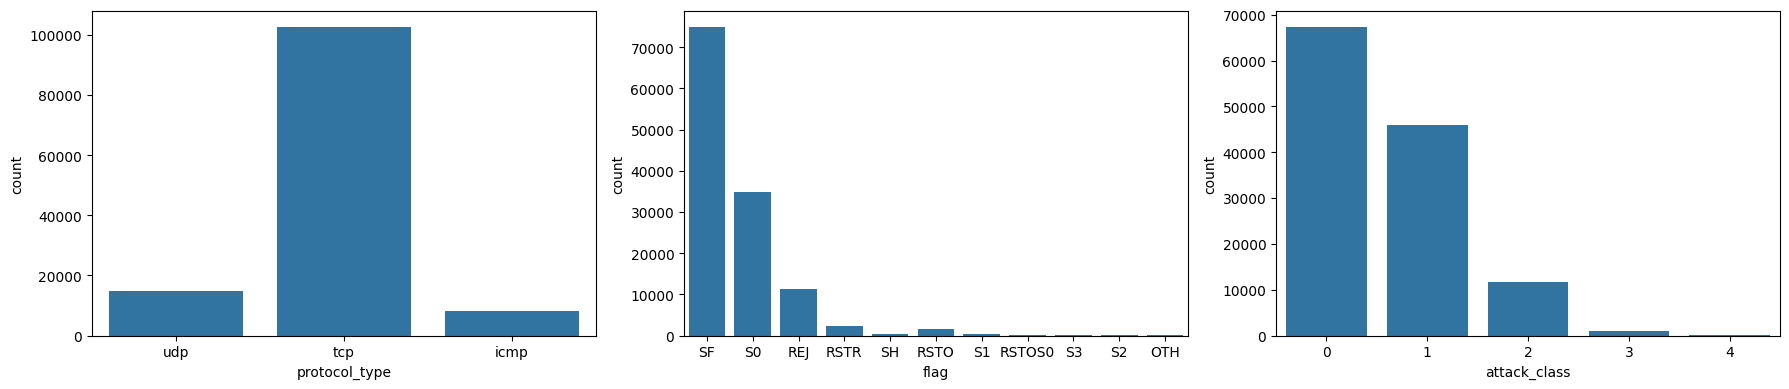

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.countplot(x="protocol_type", data=train, ax=axes[0])
sns.countplot(x="flag", data=train, ax=axes[1])
sns.countplot(x="attack_class", data=train, ax=axes[2])
plt.tight_layout()
plt.show()

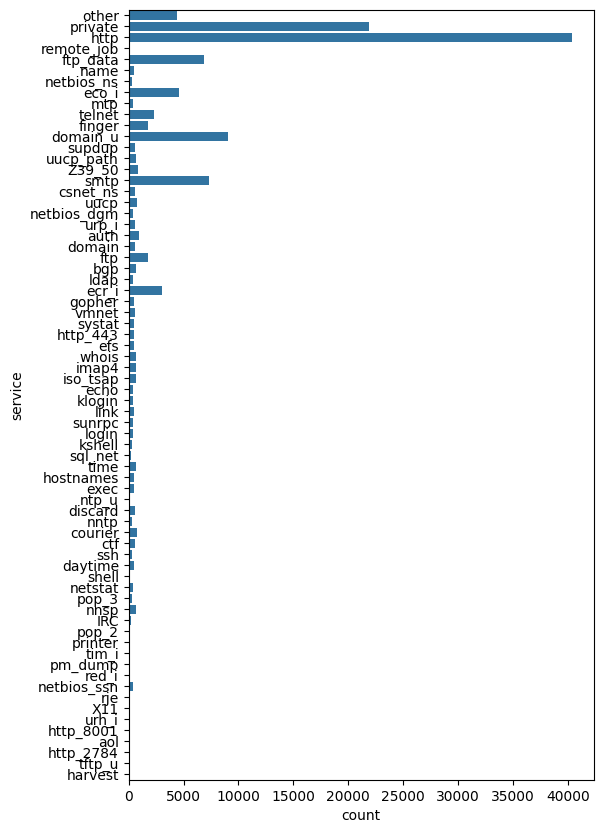

In [ ]:
plt.figure(figsize=(6, 10))
sns.countplot(y="service", data=train)
plt.show()

In [ ]:
# Separate numeric and categorical
cat_cols = ['protocol_type', 'service', 'flag', 'attack']
num_cols = [c for c in train.columns if c not in cat_cols + ['attack_class']]

train_encoded = pd.get_dummies(train, columns=['protocol_type', 'service', 'flag', 'attack'], drop_first=True)
train_encoded.head()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,level,attack_class,protocol_type_tcp,protocol_type_udp,service_X11,service_Z39_50,service_aol,service_auth,service_bgp,service_courier,service_csnet_ns,service_ctf,service_daytime,service_discard,service_domain,service_domain_u,service_echo,service_eco_i,service_ecr_i,service_efs,service_exec,service_finger,service_ftp,service_ftp_data,service_gopher,service_harvest,service_hostnames,service_http,service_http_2784,service_http_443,service_http_8001,service_imap4,service_iso_tsap,service_klogin,service_kshell,service_ldap,service_link,service_login,service_mtp,service_name,service_netbios_dgm,service_netbios_ns,service_netbios_ssn,service_netstat,service_nnsp,service_nntp,service_ntp_u,service_other,service_pm_dump,service_pop_2,service_pop_3,service_printer,service_private,service_red_i,service_remote_job,service_rje,service_shell,service_smtp,service_sql_net,service_ssh,service_sunrpc,service_supdup,service_systat,service_telnet,service_tftp_u,service_tim_i,service_time,service_urh_i,service_urp_i,service_uucp,service_uucp_path,service_vmnet,service_whois,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH,attack_buffer_overflow,attack_ftp_write,attack_guess_passwd,attack_imap,attack_ipsweep,attack_land,attack_loadmodule,attack_multihop,attack_neptune,attack_nmap,attack_normal,attack_perl,attack_phf,attack_pod,attack_portsweep,attack_rootkit,attack_satan,attack_smurf,attack_spy,attack_teardrop,attack_warezclient,attack_warezmaster
0,0,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.0,0.0,0.0,0.0,0.08,0.15,0.00,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.0,0.00,15,0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.0,1.0,0.0,0.0,0.05,0.07,0.00,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.0,0.00,19,1,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
2,0,232,8153,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,5,5,0.2,0.2,0.0,0.0,1.00,0.00,0.00,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.0,0.01,21,0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,Fal

In [ ]:
# Train/test split (BEFORE any transformations to avoid leakage)
X = train_encoded.drop('attack_class', axis=1)
y = train_encoded['attack_class']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
print(f"Train: {x_train.shape}, Test: {x_test.shape}")

Train: (88180, 142), Test: (37792, 142)


In [ ]:
def outlier_capping(series, lower_q, upper_q):
    return series.clip(lower=lower_q, upper=upper_q)

clip_bounds = {}
for col in num_cols:
    if col in x_train.columns:
        q01 = x_train[col].quantile(0.01)
        q99 = x_train[col].quantile(0.99)
        clip_bounds[col] = (q01, q99)
        x_train[col] = x_train[col].clip(lower=q01, upper=q99)
        x_test[col] = x_test[col].clip(lower=q01, upper=q99)

print("Outlier capping done (fitted on train only).")

Outlier capping done (fitted on train only).


In [ ]:
x_train.fillna(x_train.median(), inplace=True)
x_test.fillna(x_train.median(), inplace=True)  # use TRAIN median for test

print(f"NaNs in train: {x_train.isna().sum().sum()}, test: {x_test.isna().sum().sum()}")

NaNs in train: 0, test: 0


In [ ]:
selector = SelectKBest(f_classif, k=15)
selector.fit(x_train, y_train)

top_features = x_train.columns[selector.get_support()]
print("Top 15 features:", list(top_features))

x_train_sel = x_train[top_features]
x_test_sel = x_test[top_features]

Top 15 features: ['logged_in', 'count', 'serror_rate', 'srv_serror_rate', 'same_srv_rate', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'flag_S0', 'flag_SF', 'attack_buffer_overflow', 'attack_neptune', 'attack_normal', 'attack_warezclient']


In [ ]:
lr = LogisticRegression(random_state=0, solver='lbfgs', multi_class='multinomial', max_iter=1000)
lr.fit(x_train_sel, y_train)
y_pred_lr = lr.predict(x_test_sel)
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.9922
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20203
           1       1.00      0.98      0.99     13778
           2       0.94      0.99      0.96      3497
           3       1.00      0.93      0.96       298
           4       1.00      0.25      0.40        16

    accuracy                           0.99     37792
   macro avg       0.99      0.83      0.86     37792
weighted avg       0.99      0.99      0.99     37792



In [ ]:
gnb = GaussianNB()
gnb.fit(x_train_sel, y_train)
y_pred_gnb = gnb.predict(x_test_sel)
print(f"Accuracy: {accuracy_score(y_test, y_pred_gnb):.4f}")
print(classification_report(y_test, y_pred_gnb))


Accuracy: 0.9391
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20203
           1       0.99      0.89      0.94     13778
           2       0.69      0.77      0.73      3497
           3       0.36      0.93      0.52       298
           4       0.03      0.88      0.05        16

    accuracy                           0.94     37792
   macro avg       0.62      0.89      0.65     37792
weighted avg       0.96      0.94      0.95     37792



In [ ]:
bnb = BernoulliNB()
bnb.fit(x_train_sel, y_train)
y_pred_bnb = bnb.predict(x_test_sel)
print(f"Accuracy: {accuracy_score(y_test, y_pred_bnb):.4f}")
print(classification_report(y_test, y_pred_bnb))

Accuracy: 0.9531
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     20203
           1       0.98      0.89      0.93     13778
           2       0.73      0.96      0.83      3497
           3       0.50      0.94      0.65       298
           4       1.00      0.38      0.55        16

    accuracy                           0.95     37792
   macro avg       0.84      0.83      0.79     37792
weighted avg       0.96      0.95      0.96     37792



In [ ]:
nc = NearestCentroid()
nc.fit(x_train_sel, y_train)
y_pred_nc = nc.predict(x_test_sel)
print(f"Accuracy: {accuracy_score(y_test, y_pred_nc):.4f}")
print(classification_report(y_test, y_pred_nc))

Accuracy: 0.6444
              precision    recall  f1-score   support

           0       0.94      0.74      0.83     20203
           1       0.89      0.66      0.76     13778
           2       0.04      0.03      0.04      3497
           3       0.05      0.66      0.09       298
           4       0.00      0.88      0.01        16

    accuracy                           0.64     37792
   macro avg       0.39      0.59      0.34     37792
weighted avg       0.83      0.64      0.72     37792



In [ ]:
rfc = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rfc.fit(x_train_sel, y_train)
y_pred_rfc = rfc.predict(x_test_sel)
print(f"Accuracy: {accuracy_score(y_test, y_pred_rfc):.4f}")
print(classification_report(y_test, y_pred_rfc))

Accuracy: 0.9973
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20203
           1       1.00      1.00      1.00     13778
           2       0.98      0.99      0.99      3497
           3       0.98      0.97      0.98       298
           4       0.89      0.50      0.64        16

    accuracy                           1.00     37792
   macro avg       0.97      0.89      0.92     37792
weighted avg       1.00      1.00      1.00     37792



In [ ]:
xgb_clf = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    objective='multi:softmax',
    num_class=5,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)
xgb_clf.fit(x_train_sel, y_train)
y_pred_xgb = xgb_clf.predict(x_test_sel)
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.9977
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20203
           1       1.00      1.00      1.00     13778
           2       0.99      0.99      0.99      3497
           3       0.99      0.98      0.98       298
           4       0.89      0.50      0.64        16

    accuracy                           1.00     37792
   macro avg       0.97      0.89      0.92     37792
weighted avg       1.00      1.00      1.00     37792



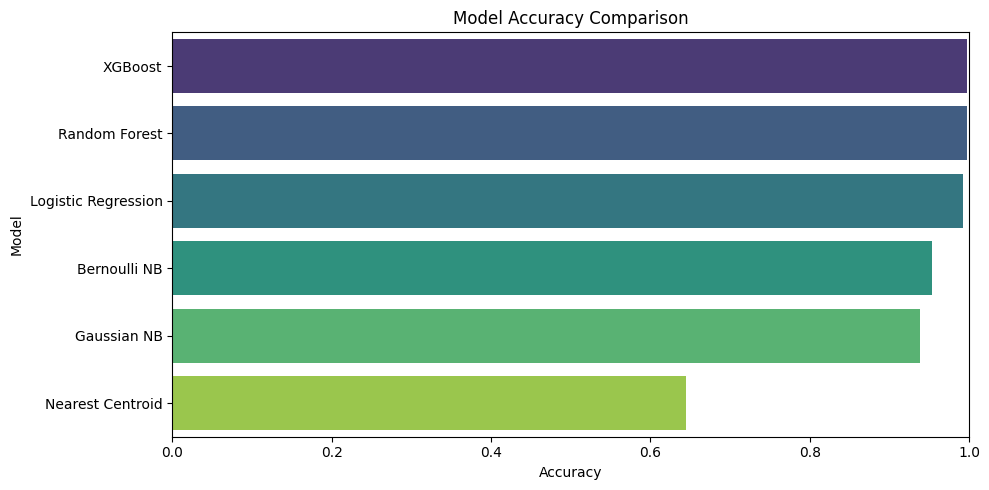

              Model  Accuracy
            XGBoost  0.997671
      Random Forest  0.997301
Logistic Regression  0.992221
       Bernoulli NB  0.953059
        Gaussian NB  0.939061
   Nearest Centroid  0.644396


In [ ]:
results = {
    'Logistic Regression': accuracy_score(y_test, y_pred_lr),
    'Gaussian NB': accuracy_score(y_test, y_pred_gnb),
    'Bernoulli NB': accuracy_score(y_test, y_pred_bnb),
    'Nearest Centroid': accuracy_score(y_test, y_pred_nc),
    'Random Forest': accuracy_score(y_test, y_pred_rfc),
    'XGBoost': accuracy_score(y_test, y_pred_xgb),
}

results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values('Accuracy', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Accuracy', y='Model', data=results_df, palette='viridis')
plt.xlim(0, 1)
plt.title('Model Accuracy Comparison')
plt.tight_layout()
plt.show()
print(results_df.to_string(index=False))

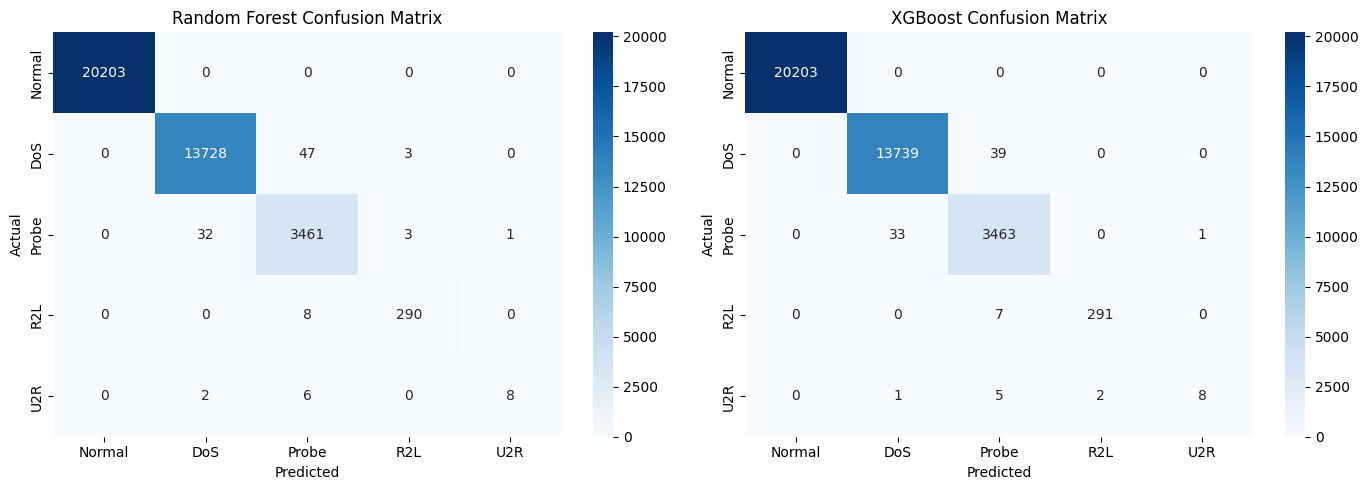

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
class_names = ['Normal', 'DoS', 'Probe', 'R2L', 'U2R']

for ax, y_pred, title in [(axes[0], y_pred_rfc, 'Random Forest'), (axes[1], y_pred_xgb, 'XGBoost')]:
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f'{title} Confusion Matrix')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

In [ ]:
# SHAP for Random Forest
sample_size = min(500, len(x_test_sel))
x_sample = x_test_sel.sample(n=sample_size, random_state=42)

rfc_explainer = shap.TreeExplainer(rfc)
rfc_shap_values = rfc_explainer.shap_values(x_sample)

print("SHAP values shape:", np.array(rfc_shap_values).shape)
print("Classes: Normal(0), DoS(1), Probe(2), R2L(3), U2R(4)")

SHAP values shape: (500, 15, 5)
Classes: Normal(0), DoS(1), Probe(2), R2L(3), U2R(4)


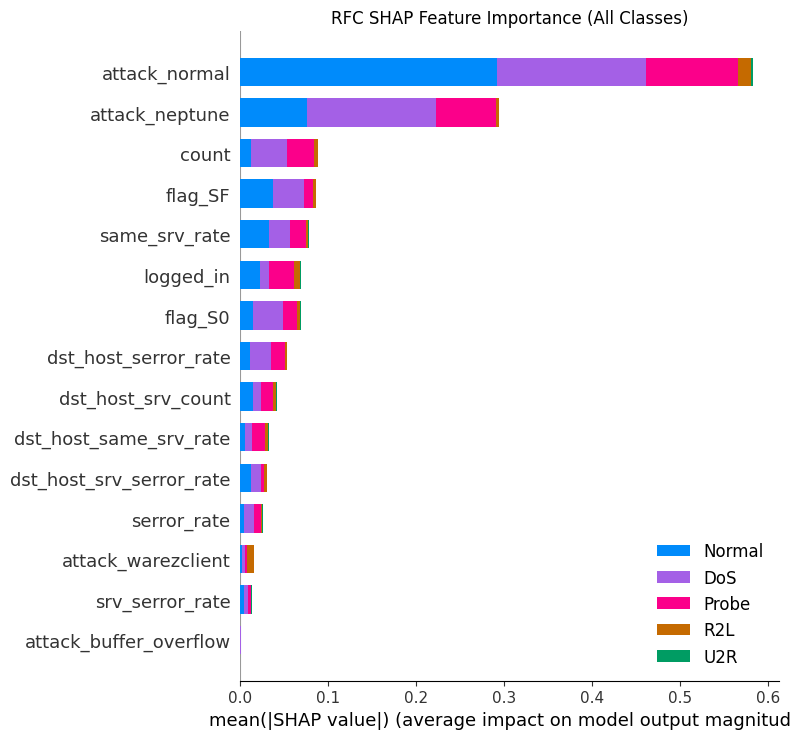

In [ ]:
# SHAP Summary Plot — Random Forest (all classes)
plt.figure()
shap.summary_plot(rfc_shap_values, x_sample, plot_type="bar", class_names=['Normal','DoS','Probe','R2L','U2R'], show=False)
plt.title("RFC SHAP Feature Importance (All Classes)")
plt.tight_layout()
plt.show()

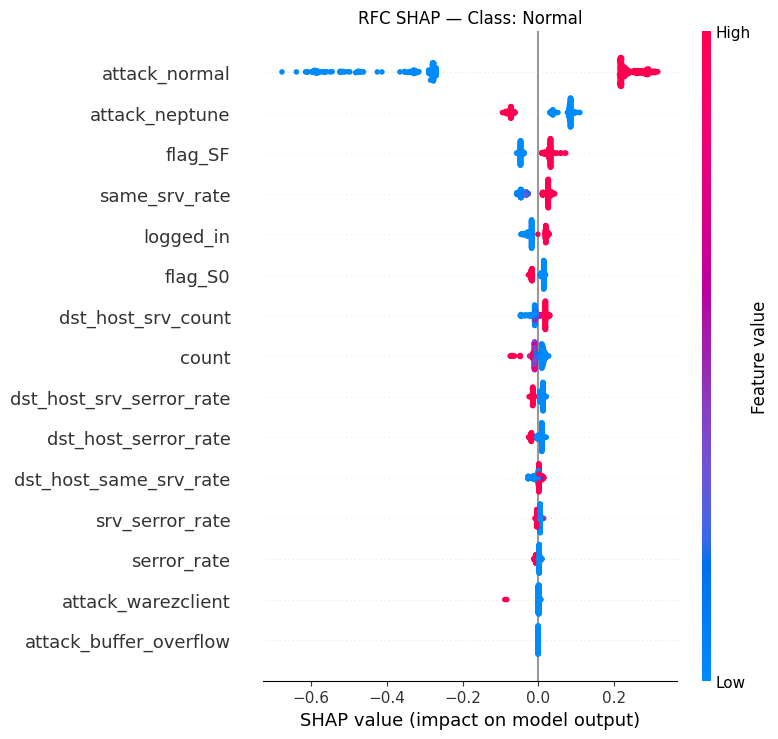

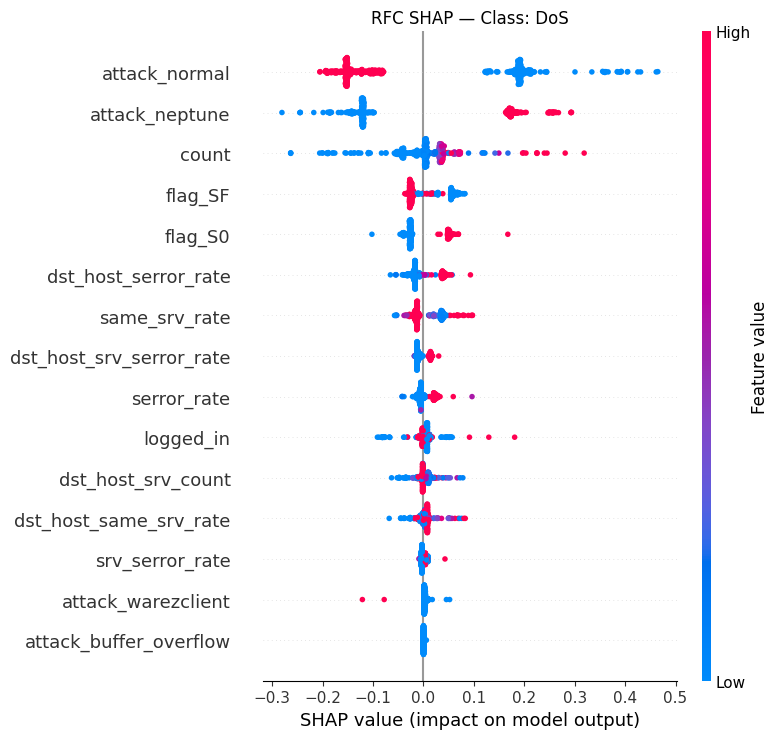

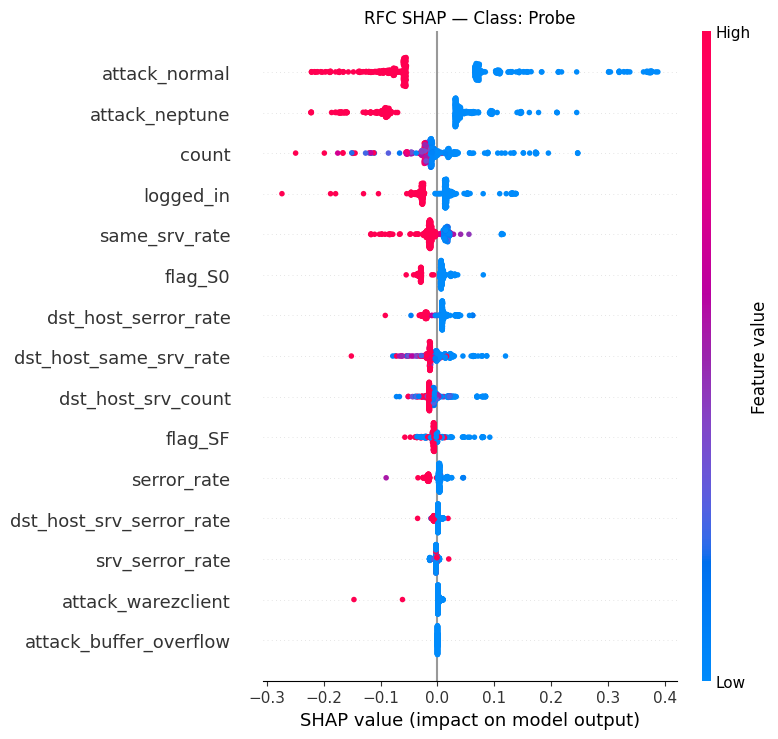

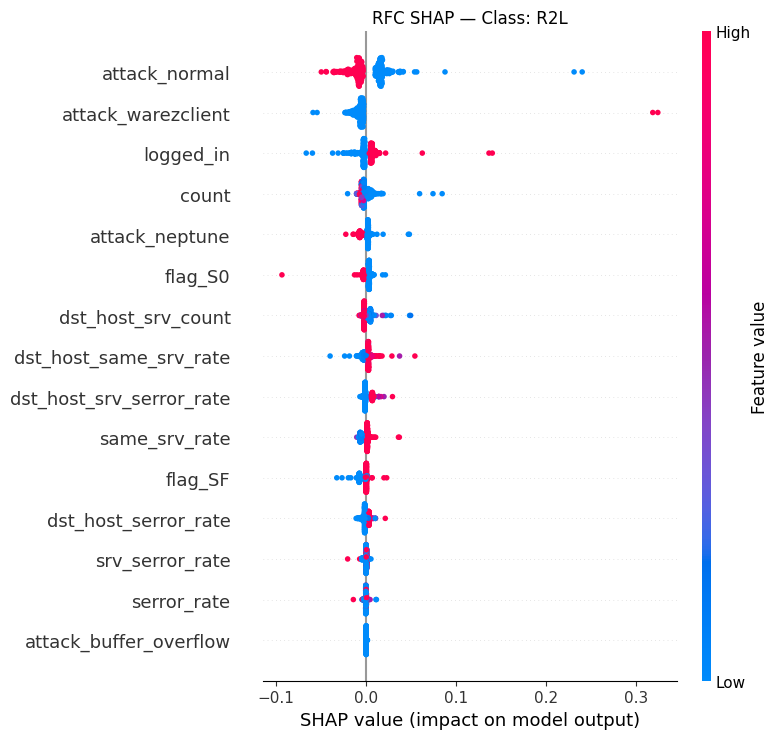

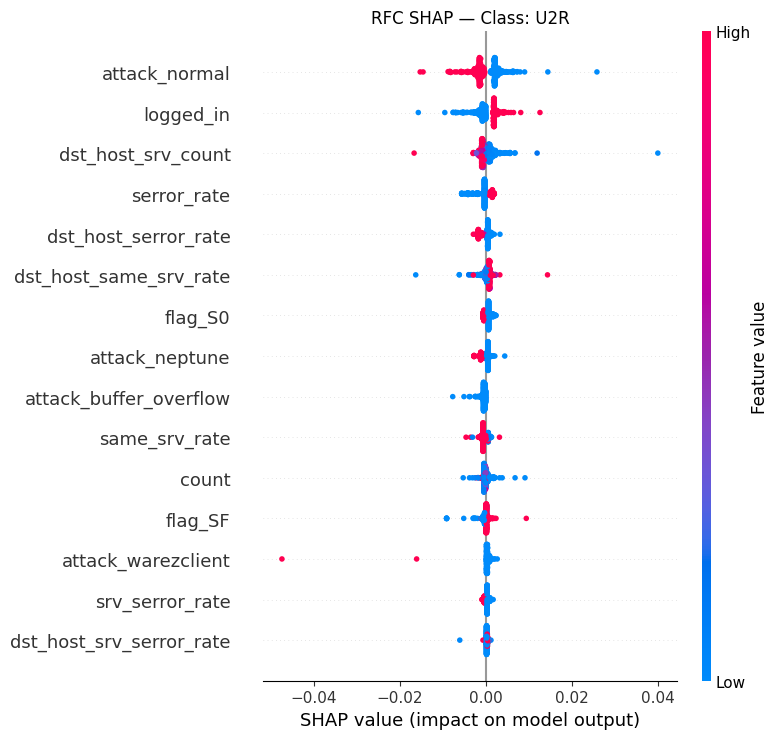

In [ ]:
import numpy as np

for i, cls in enumerate(['Normal','DoS','Probe','R2L','U2R']):
    plt.figure()
    # Extract SHAP values for the current class across all samples
    shap_values_for_current_class = np.array([sample_values[:, i] for sample_values in rfc_shap_values])
    shap.summary_plot(shap_values_for_current_class, x_sample, show=False)
    plt.title(f"RFC SHAP — Class: {cls}")
    plt.tight_layout()
    plt.show()

In [ ]:
# SHAP for XGBoost
xgb_explainer = shap.TreeExplainer(xgb_clf)
xgb_shap_values = xgb_explainer.shap_values(x_sample)

print("SHAP values shape:", np.array(xgb_shap_values).shape)

SHAP values shape: (500, 15, 5)


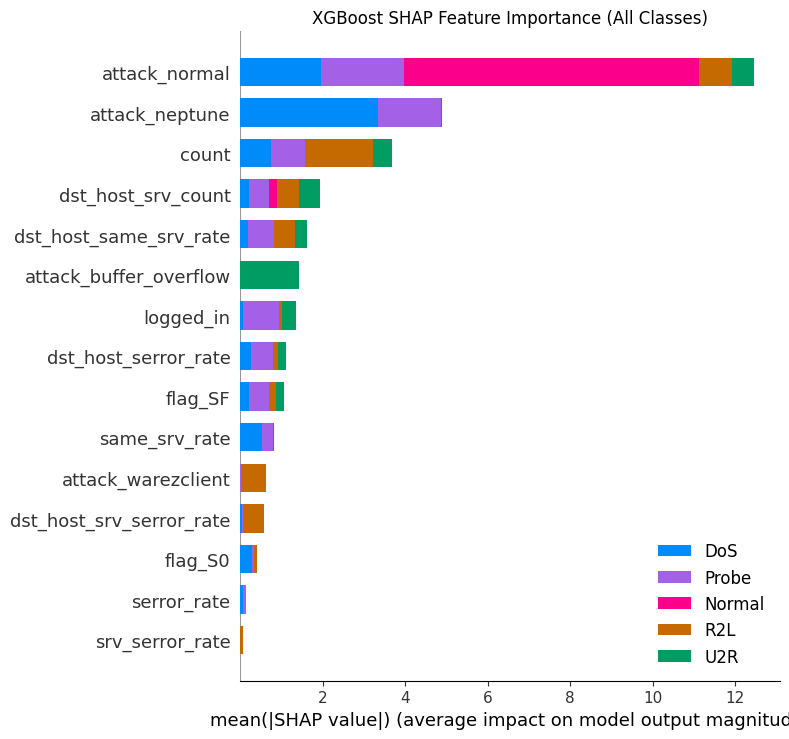

In [ ]:
# SHAP Summary Plot — XGBoost (all classes)
plt.figure()
shap.summary_plot(xgb_shap_values, x_sample, plot_type="bar", class_names=['Normal','DoS','Probe','R2L','U2R'], show=False)
plt.title("XGBoost SHAP Feature Importance (All Classes)")
plt.tight_layout()
plt.show()

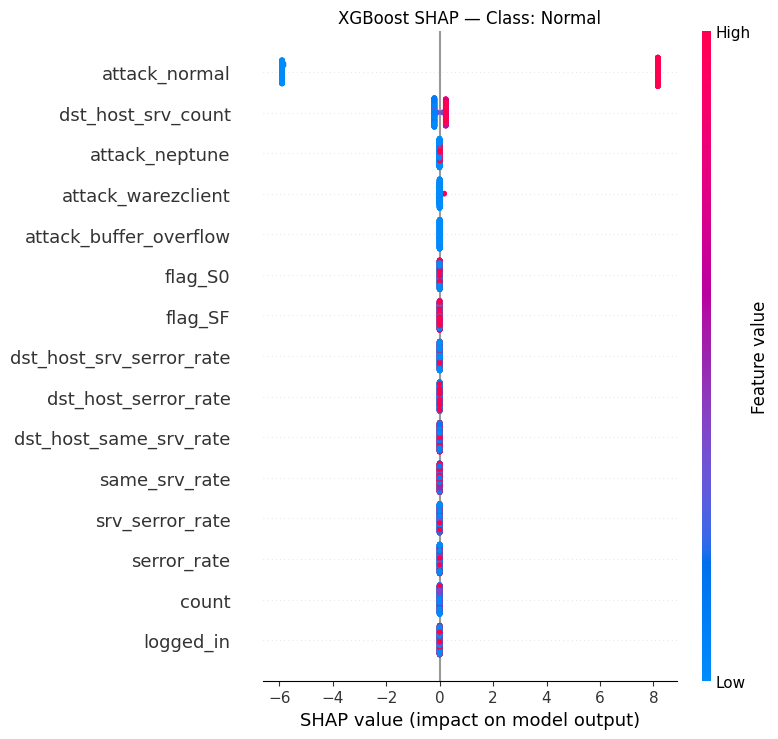

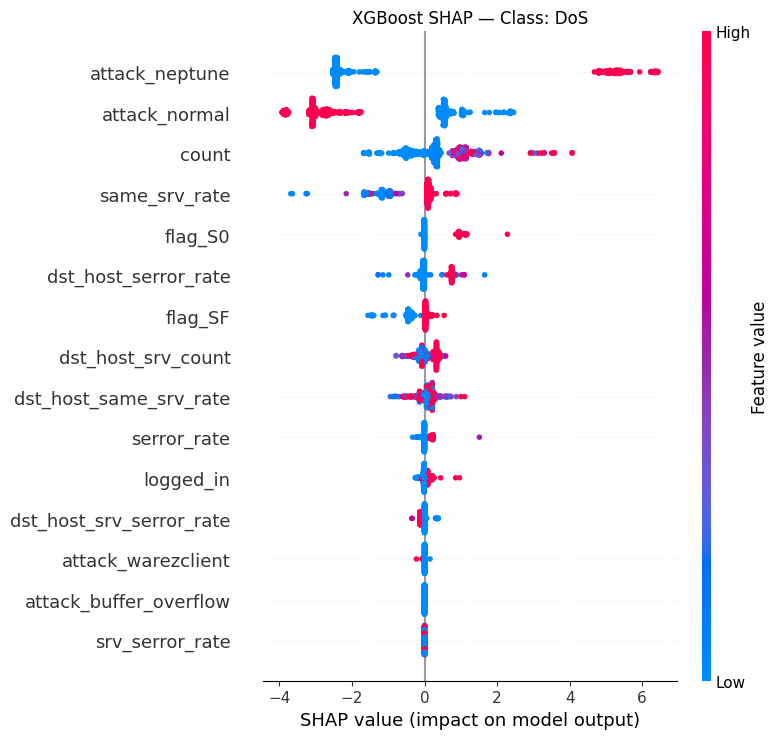

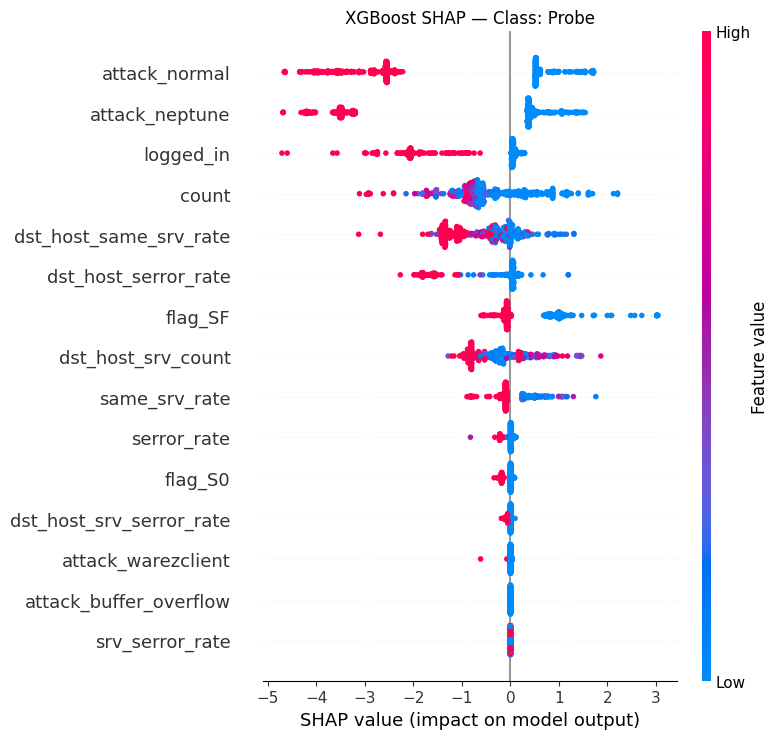

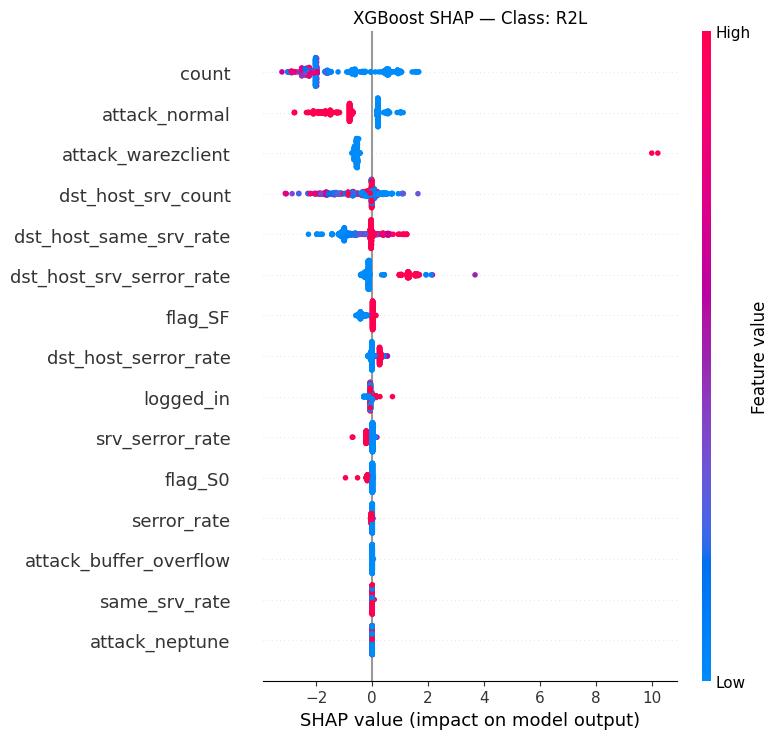

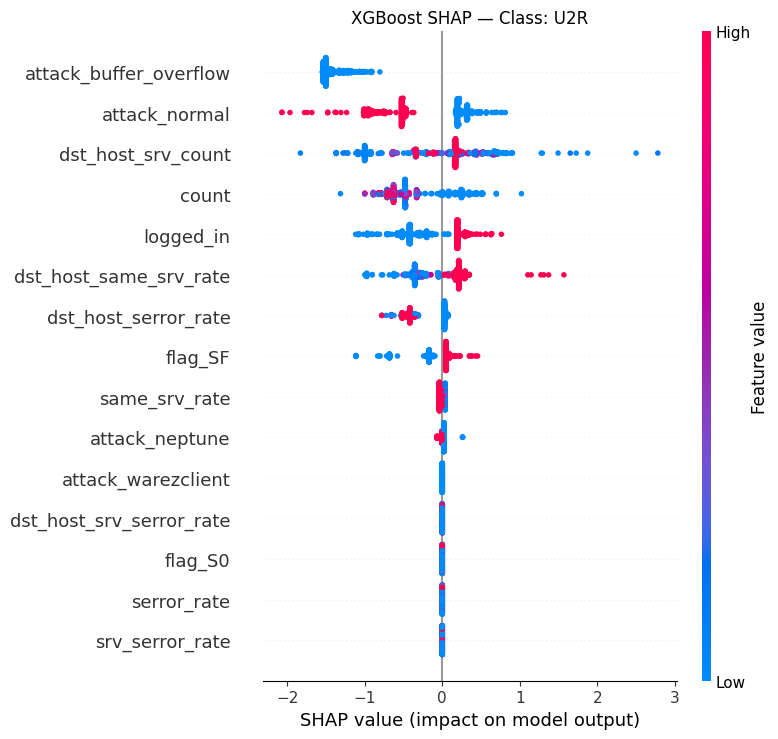

In [ ]:
# SHAP Summary Plot — XGBoost per class
import numpy as np

for i, cls in enumerate(['Normal','DoS','Probe','R2L','U2R']):
    plt.figure()
    # Extract SHAP values for the current class across all samples
    shap_values_for_current_class = np.array([sample_values[:, i] for sample_values in xgb_shap_values])
    shap.summary_plot(shap_values_for_current_class, x_sample, show=False)
    plt.title(f"XGBoost SHAP — Class: {cls}")
    plt.tight_layout()
    plt.show()

True label: 0
RFC prediction: 0


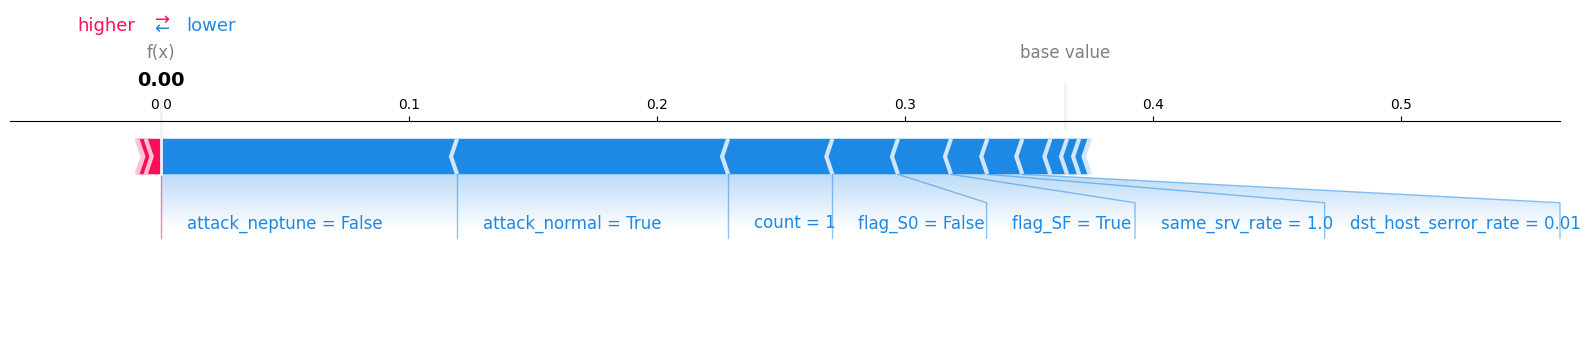

In [ ]:
shap.initjs()

# Convert SHAP values to list-of-arrays if 3D ndarray (newer SHAP versions)
if isinstance(rfc_shap_values, np.ndarray) and rfc_shap_values.ndim == 3:
    rfc_shap_values = [rfc_shap_values[i] for i in range(rfc_shap_values.shape[0])]
if isinstance(xgb_shap_values, np.ndarray) and xgb_shap_values.ndim == 3:
    xgb_shap_values = [xgb_shap_values[i] for i in range(xgb_shap_values.shape[0])]

# Single prediction explanation — Random Forest
idx = 92
true_label = y_test.loc[x_sample.index[idx]]
print(f"True label: {true_label}")
print(f"RFC prediction: {rfc.predict(x_sample.iloc[[idx]])[0]}")
shap.force_plot(rfc_explainer.expected_value[1], rfc_shap_values[idx][:, 1], x_sample.iloc[[idx]], matplotlib=True)

XGBoost prediction: 0


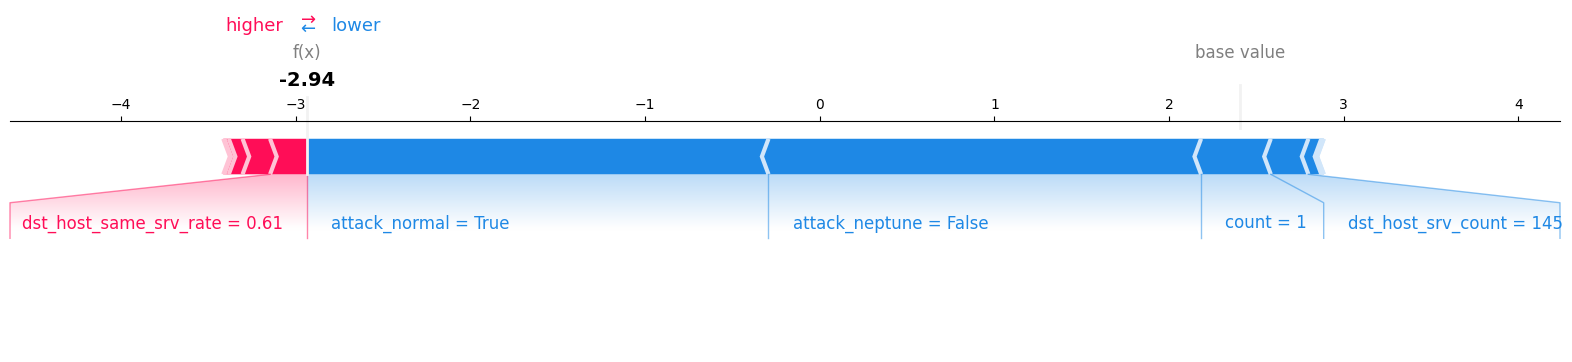

In [ ]:
# Single prediction explanation — XGBoost
print(f"XGBoost prediction: {xgb_clf.predict(x_sample.iloc[[idx]])[0]}")
shap.force_plot(xgb_explainer.expected_value[1], xgb_shap_values[idx][:, 1], x_sample.iloc[[idx]], matplotlib=True)

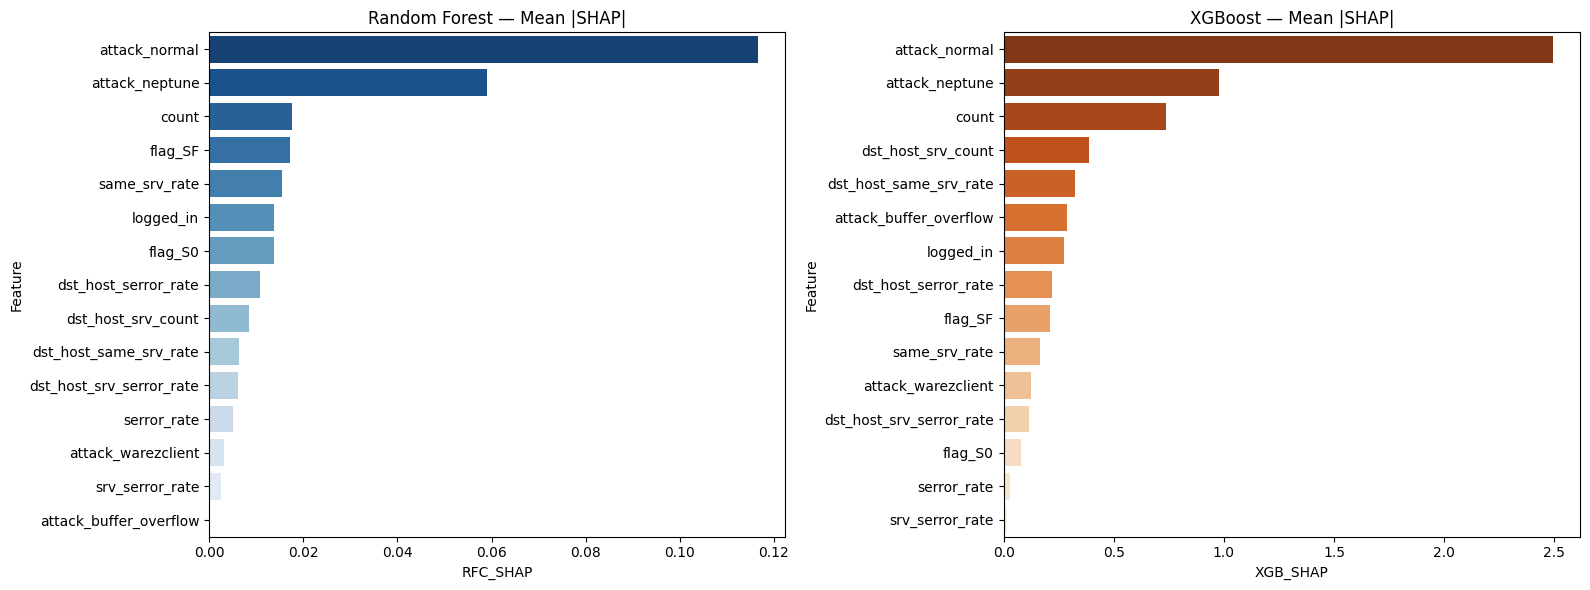

                 Feature  RFC_SHAP  XGB_SHAP
           attack_normal  0.116590  2.492836
          attack_neptune  0.058938  0.979650
                   count  0.017720  0.735149
                 flag_SF  0.017214  0.211134
           same_srv_rate  0.015591  0.166107
               logged_in  0.013847  0.271932
                 flag_S0  0.013732  0.079144
    dst_host_serror_rate  0.010739  0.220173
      dst_host_srv_count  0.008413  0.387422
  dst_host_same_srv_rate  0.006469  0.325535
dst_host_srv_serror_rate  0.006122  0.116265
             serror_rate  0.005152  0.028877
      attack_warezclient  0.003200  0.123127
         srv_serror_rate  0.002634  0.013922
  attack_buffer_overflow  0.000220  0.285623


In [ ]:
rfc_importance = np.mean([np.abs(s_vals).mean(axis=1) for s_vals in rfc_shap_values], axis=0)
xgb_importance = np.mean([np.abs(s_vals).mean(axis=1) for s_vals in xgb_shap_values], axis=0)

comparison_df = pd.DataFrame({
    'Feature': top_features,
    'RFC_SHAP': rfc_importance,
    'XGB_SHAP': xgb_importance
}).sort_values('RFC_SHAP', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x='RFC_SHAP', y='Feature', data=comparison_df.sort_values('RFC_SHAP', ascending=False), ax=axes[0], palette='Blues_r')
axes[0].set_title('Random Forest — Mean |SHAP|')
sns.barplot(x='XGB_SHAP', y='Feature', data=comparison_df.sort_values('XGB_SHAP', ascending=False), ax=axes[1], palette='Oranges_r')
axes[1].set_title('XGBoost — Mean |SHAP|')
plt.tight_layout()
plt.show()

print(comparison_df.to_string(index=False))